In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('datasets/results-kaggle.csv')
df

,Vectorizer,Model,Train_Accuracy,Train_F1,Test_Accuracy,Test_F1,Inference_Time,FLOPs_per_Sample,Training_Time
0,BOW,Logistic Model,0.929450,0.929328,0.902237,0.902075,0.136527,1.000000e+04,4.875000
1,BOW,Random Forest Model,0.789375,0.788256,0.781579,0.779980,0.210410,1.000000e+03,7.531250
2,BOW,XG Boost Model,0.930625,0.930504,0.904605,0.904392,0.184776,4.000000e+03,63.421875
3,BOW,MLP Model,0.949333,0.949257,0.913026,0.912820,1.236788,2.626560e+06,53.453125
4,BOW,Scratch MLP Model,0.920692,0.920560,0.902895,0.902761,3.453125,2.626560e+06,1562.906250
5,Tf_IDF,Logistic Model,0.919283,0.919100,0.905658,0.905387,0.302151,1.000000e+04,10.062500
6,Tf_IDF,Random Forest Model,0.778833,0.779300,0.768684,0.768673,0.341379,1.000000e+03,17.015625
7,Tf_IDF,XG Boost Model,0.936292,0.936206,0.903026,0.902790,0.376454,4.000000e+03,2439.328125
8,Tf_IDF,MLP Model,0.930417,0.930338,0.905263,0.905156,1.405875,2.626560e+06,49.234375
9,Tf_IDF,Scratch MLP Model,0.896383,0.896034,0.888026,0.887549,3.312500,2.626560e+06,1473.250000


## Visualizations:

### Bar Plot:
    How computationally heavy each model is.

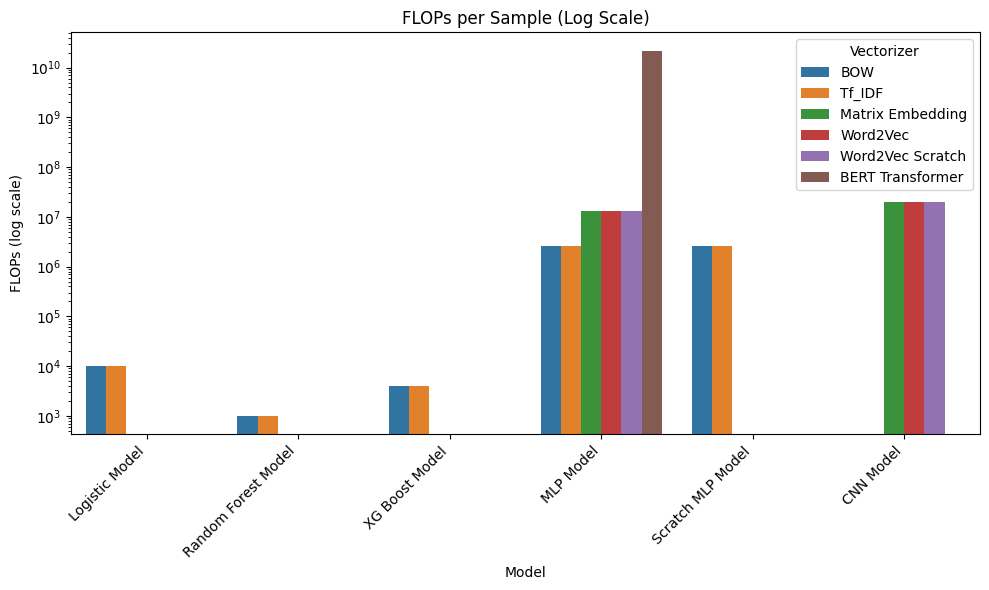

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


plt.figure(figsize=(10,6))
sns.barplot(data=df, x="Model", y="FLOPs_per_Sample", hue="Vectorizer")

plt.yscale("log")
plt.xticks(rotation=45, ha="right")
plt.title("FLOPs per Sample (Log Scale)")
plt.ylabel("FLOPs (log scale)")
plt.xlabel("Model")

plt.tight_layout()
plt.savefig('images/flops_comparison.png')
plt.show()


### Test Accuracy per Vectorizer and Model:
    helps us understand which vectorizer , model combination performs best.

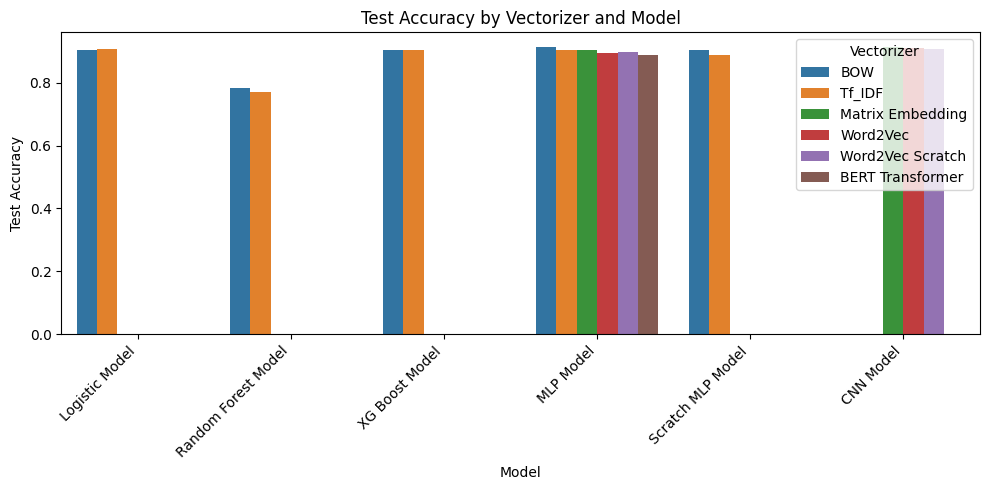

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Model", y="Test_Accuracy", hue="Vectorizer")
plt.xticks(rotation=45, ha="right")
plt.title("Test Accuracy by Vectorizer and Model")
plt.ylabel("Test Accuracy")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig('images/test_acc_vec.png')
plt.show()


### Inference Time per combination of Vectorizer and Model:
    Helps us understand and compare the inference time for test dataset.

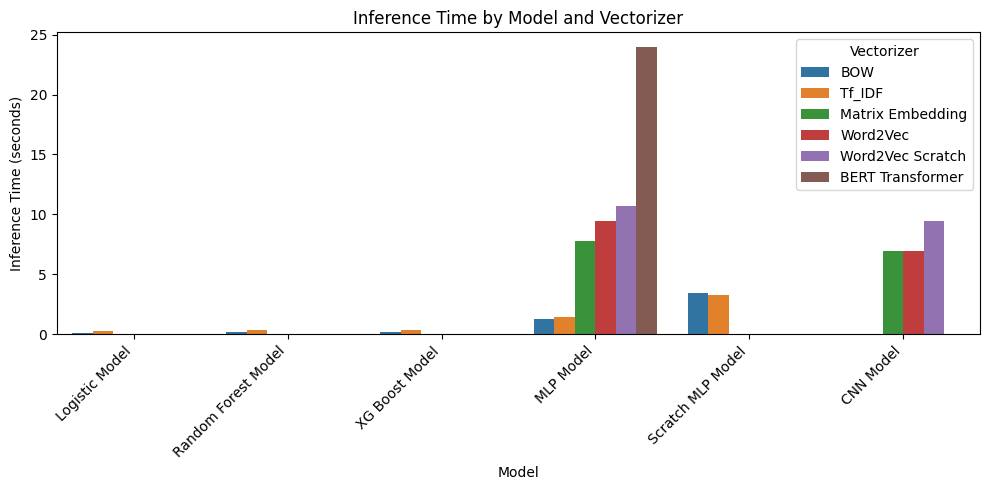

In [11]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Model", y="Inference_Time", hue="Vectorizer")
plt.xticks(rotation=45, ha="right")
plt.title("Inference Time by Model and Vectorizer")
plt.ylabel("Inference Time (seconds)")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig('images/inf_time_per_comb.png')
plt.show()


### Training Time per combination of Vectorizer and Model:
    helps us compare and understand the training time for each combination of vectorizer and model.

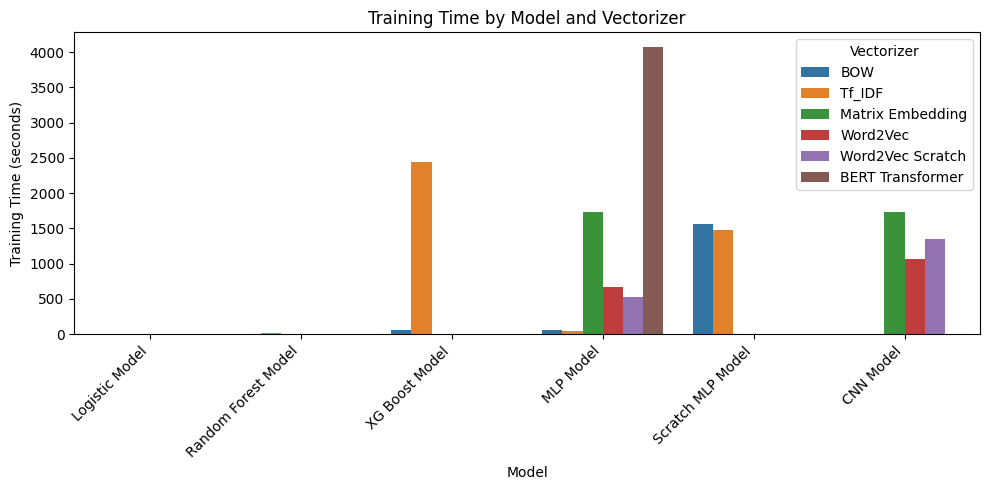

In [12]:
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Model", y="Training_Time", hue="Vectorizer")
plt.xticks(rotation=45, ha="right")
plt.title("Training Time by Model and Vectorizer")
plt.ylabel("Training Time (seconds)")
plt.xlabel("Model")
plt.tight_layout()
plt.savefig('images/training_time_comb.png')
plt.show()


### Train vs Test

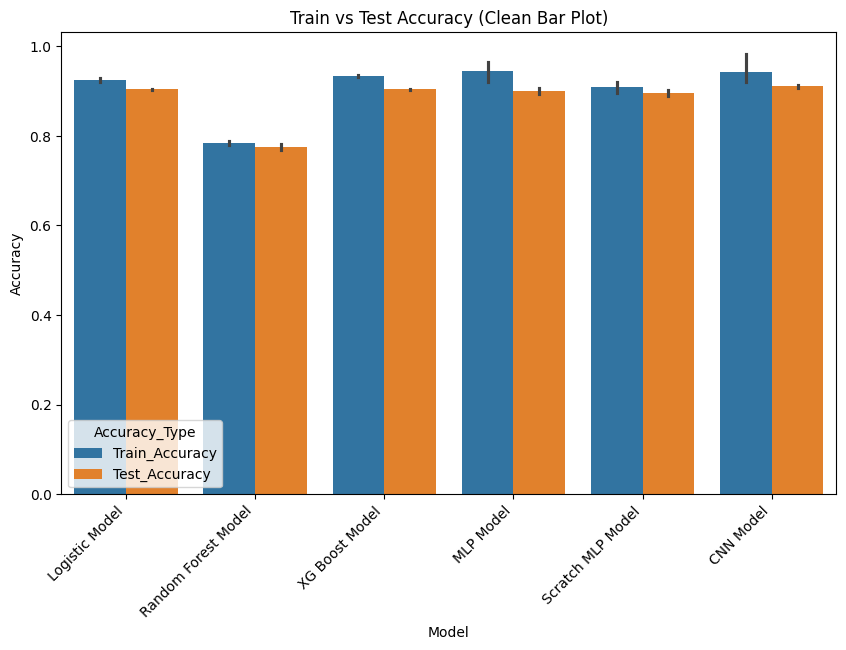

In [15]:
plt.figure(figsize=(10,6))

df_melted = df.melt(id_vars=["Vectorizer","Model"],
                    value_vars=["Train_Accuracy","Test_Accuracy"],
                    var_name="Accuracy_Type",
                    value_name="Accuracy")

sns.barplot(
    data=df_melted,
    x="Model",
    y="Accuracy",
    hue="Accuracy_Type"
)

plt.xticks(rotation=45, ha="right")
plt.title("Train vs Test Accuracy (Clean Bar Plot)")
plt.show()
